In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import importlib
import pymannkendall as mk
from sklearn.linear_model import LinearRegression

# python source path
sys.path.append('../Src/')
# Set seed
SEED = 1776

# custom python
import utils
import mapping_dict

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    "Sk-Learn": sys.modules['sklearn'].__version__,
    "Mann-Kendall Test": sys.modules['pymannkendall'].__version__
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
# reset options
# pd.reset_option('display.max_columns')

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_cat8 = pd.ArrowDtype(pa.dictionary(index_type=pa.int8(), value_type=pa.string()))

             Library Version
0             Python  3.13.9
1             Pandas   2.3.3
2              NumPy   2.3.4
3            Seaborn  0.13.2
4            Matplot  3.10.7
5           Sk-Learn   1.7.2
6  Mann-Kendall Test   1.4.3


## Data Import

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,sector,ward,community_code,community_name,community_area,fbi_code,x_coordinate,y_coordinate,year,latitude,longitude,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location
0,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,0324,003,1,<NA>,<NA>,<NA>,<NA>,18,1189075,1857566,2001,41.764219,-87.582549,January,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing
1,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,0624,006,2,08,69,GREATER GRAND CROSSING,98853167.7093,06,1184198,1855214,2003,41.75788,-87.600498,July,Saturday,Q3,2003-Q3,Evening,Larceny – Theft,True,Gresham
2,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,True,False,1122,011,4,27,23,HUMBOLDT PARK,100480876.502,18,1151273,1903996,2004,41.892451,-87.719888,December,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison
3,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,2512,025,5,29,19,BELMONT CRAGIN,109099414.689,05,1133296,1916864,2006,41.928096,-87.78561,March,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central
4,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,True,False,2522,025,5,31,19,BELMONT CRAGIN,109099414.689,18,1143697,1914371,2007,41.921066,-87.747452,May,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central


In [3]:
# Check for NaNs
utils.any_nans(df)

--- Missing Values Found (Total Rows: 8,469,443) ---
                       Count Percentage
community_code        483104    5.7041%
community_name        483104    5.7041%
community_area        483104    5.7041%
ward                  481553    5.6858%
location_description   15338    0.1811%
x_coordinate            9366    0.1106%
y_coordinate            9366    0.1106%
latitude                9366    0.1106%
longitude               9366    0.1106%
district                  12    0.0001%
sector                    12    0.0001%
district_location         12    0.0001%


## Add Year-Week Number

In [4]:
# year & Week Number
df["year_week"] = df["date"].dt.strftime("%G-%V")
# Convert datatype
df["year_week"] = df["year_week"].astype(arrow_string)
# display
df[['date', 'year_week']].head()

,date,year_week
0,2001-01-24 20:45:00,2001-04
1,2003-07-12 17:00:00,2003-28
2,2004-12-13 21:15:00,2004-51
3,2006-03-31 09:15:00,2006-13
4,2007-05-25 14:51:00,2007-21


## WHO COVID Timeline
In **March 2020**, the WHO officially declared the COVID-19 outbreak a pandemic. In **May 2023**, the WHO declared an end to the public health emergency of international concern.

In [5]:
# Covid Time Line
start = pd.Timestamp("2020-03-01")
end   = pd.Timestamp("2023-03-31")

# Conditional
conditions = [
    df["date"] < start,
    df["date"].between(start, end),
    df["date"] > end
]
# Choices for new column
choices = ["pre_covid", "covid", "post_covid"]
# New column
df["covid_period"] = np.select(
    conditions,
    choices,
    default="unknown"
)

# Change datatype
df.covid_period = df.covid_period.astype(arrow_string)
# display
df.sample(n=5, random_state=SEED)

,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,sector,ward,community_code,community_name,community_area,fbi_code,x_coordinate,y_coordinate,year,latitude,longitude,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,year_week,covid_period
1667796,HK459406,2004-06-27 23:55:00,038XX N RIDGEWAY AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,OTHER,False,False,1732,017,5,39,16,IRVING PARK,89611382.3106,14,1150710,1925213,2004,41.950683,-87.7214,June,Sunday,Q2,2004-Q2,Night,Vandalism,False,Albany Park,2004-26,pre_covid
3620492,HP674680,2008-11-09 16:44:00,029XX N ELSTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,True,1411,014,5,01,21,AVONDALE,55290595.473,14,1158773,1919554,2008,41.934993,-87.691917,November,Sunday,Q4,2008-Q4,Evening,Vandalism,False,Shakespeare,2008-45,pre_covid
375450,G613442,2001-10-10 23:30:00,053XX S PAULINA ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,0932,009,1,<NA>,<NA>,<NA>,<NA>,14,1165873,1869440,2001,41.797327,-87.667253,October,Wednesday,Q4,2001-Q4,Night,Vandalism,False,Deering,2001-41,pre_covid
4194960,HS300643,2010-05-10 15:00:00,003XX E 70TH ST,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,0322,003,1,06,69,GREATER GRAND CROSSING,98853167.7093,18,1179822,1858685,2010,41.767506,-87.616429,May,Monday,Q2,2010-Q2,Afternoon,Drug Abuse Violations,False,Grand Crossing,2010-19,pre_covid
6769633,JB554155,2018-12-15 08:30:00,028XX E 76TH ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,0421,004,2,07,43,SOUTH SHORE,81812716.3958,08B,1196271,1855505,2018,41.758388,-87.556243,December,Saturday,Q4,2018-Q4,Morning,Simple Battery,False,South Chicago,2018-50,pre_covid


In [6]:
# display number of unique values
for i in df.columns:
    print(f"{i}: {df[i].nunique():,}")

case_number: 8,469,443
date: 3,545,621
block: 65,509
iucr: 418
primary_type: 34
description: 569
location_description: 183
arrest: 2
domestic: 2
beat: 305
district: 22
sector: 5
ward: 50
community_code: 77
community_name: 77
community_area: 77
fbi_code: 26
x_coordinate: 79,348
y_coordinate: 130,433
year: 25
latitude: 909,236
longitude: 908,634
month: 12
day_of_week: 7
quarter: 4
year_quarter: 100
time_of_day: 6
fbi_code_desc: 26
fbi_index_code: 2
district_location: 22
year_week: 1,304
covid_period: 3


In [7]:
print(df.covid_period.unique())

<ArrowExtensionArray>
['pre_covid', 'post_covid', 'covid']
Length: 3, dtype: string[pyarrow]


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469443 entries, 0 to 8469442
Data columns (total 32 columns):
 #   Column                Dtype                
---  ------                -----                
 0   case_number           string[pyarrow]      
 1   date                  timestamp[s][pyarrow]
 2   block                 string[pyarrow]      
 3   iucr                  string[pyarrow]      
 4   primary_type          string[pyarrow]      
 5   description           string[pyarrow]      
 6   location_description  string[pyarrow]      
 7   arrest                bool[pyarrow]        
 8   domestic              bool[pyarrow]        
 9   beat                  string[pyarrow]      
 10  district              string[pyarrow]      
 11  sector                string[pyarrow]      
 12  ward                  string[pyarrow]      
 13  community_code        string[pyarrow]      
 14  community_name        string[pyarrow]      
 15  community_area        double[pyarrow]      
 16  

## Category

In [9]:
# Create New Columns: map: runs vectorized, column‑level operations.
df['Indexed'] = (
    df['fbi_index_code']
        .map({True: 'I', False: 'N'})
        .astype(arrow_cat8)
)

# Column List 
cols = ['fbi_code_desc', 'month', 'day_of_week', 'time_of_day', 'quarter', 'covid_period']
# Convert columns to Arrow dictionary (unordered)
for col in cols:
    df[col] = df[col].astype(arrow_cat8)

## MultiIndex DataFrame

In [10]:
# Group and count
multi_counts = (df.groupby(['fbi_code_desc', 'quarter', 'month', 'day_of_week', 'time_of_day', 'Indexed', 'year_week', 'covid_period']).size())
multi_counts.isna().any()

np.False_

In [11]:
# Index names
multi_counts.index.names

FrozenList(['fbi_code_desc', 'quarter', 'month', 'day_of_week', 'time_of_day', 'Indexed', 'year_week', 'covid_period'])

In [12]:
# Distinct Crime Type Values
print(list(multi_counts.index.get_level_values('fbi_code_desc').unique()))

['Aggravated Assault', 'Aggravated Battery', 'Arson', 'Burglary', 'Criminal Sexual Assault', 'Disorderly Conduct', 'Drug Abuse Violations', 'Embezzlement', 'Forgery and Counterfeiting', 'Fraud', 'Gambling', 'Homicide – 1st or 2nd Degree', 'Involuntary Manslaughter / Reckless Homicide', 'Larceny – Theft', 'Liquor Laws', 'Miscellaneous Non-Index Offenses', 'Motor Vehicle Theft', 'Offenses Against Family and Children', 'Prostitution', 'Robbery', 'Sex Offense – Criminal Sexual Abuse', 'Simple Assault', 'Simple Battery', 'Stolen Property (Buy, Receive, Possess)', 'Vandalism', 'Weapons Violations']


### COVID vs Non‑COVID Proportional Comparison

In [13]:
totals = (multi_counts.groupby(['fbi_code_desc', 'Indexed', 'covid_period']).sum())
# display
totals.head()

fbi_code_desc       Indexed  covid_period
Aggravated Assault  I        covid            21535
                             post_covid       20515
                             pre_covid       114800
Aggravated Battery  I        covid            24767
                             post_covid       21599
dtype: int64

In [14]:
# Consolidate to DataFrame
df_is_covid = (totals.groupby(level=["fbi_code_desc", "covid_period"]).sum().rename("total_crime")).to_frame(name="crime_count")
# Display
df_is_covid.head()

crime_count
fbi_code_desc      covid_period             
Aggravated Assault covid               21535
                   post_covid          20515
                   pre_covid          114800
Aggravated Battery covid               24767
                   post_covid          21599

#### Percentage of Crime

In [15]:
# Selects the second level of your MultiIndex
# df_is_covid.xs(True, level="is_covid")["crime_count"].sum()
# df_is_covid.loc[df_is_covid.index.get_level_values(1) == True, 'crime_count'].sum()
# Compute percentages within each crime type (two-group and select only the crime_count column)
df_is_covid["crime_proportion"] = (df_is_covid.crime_count / df_is_covid.groupby('covid_period')['crime_count']
                                        .transform('sum') # computes the sum of crime_count for each group
                                  )
# display
df_is_covid.head()

crime_count  crime_proportion
fbi_code_desc      covid_period                               
Aggravated Assault covid               21535          0.031496
                   post_covid          20515          0.029601
                   pre_covid          114800          0.016186
Aggravated Battery covid               24767          0.036223
                   post_covid          21599          0.031165

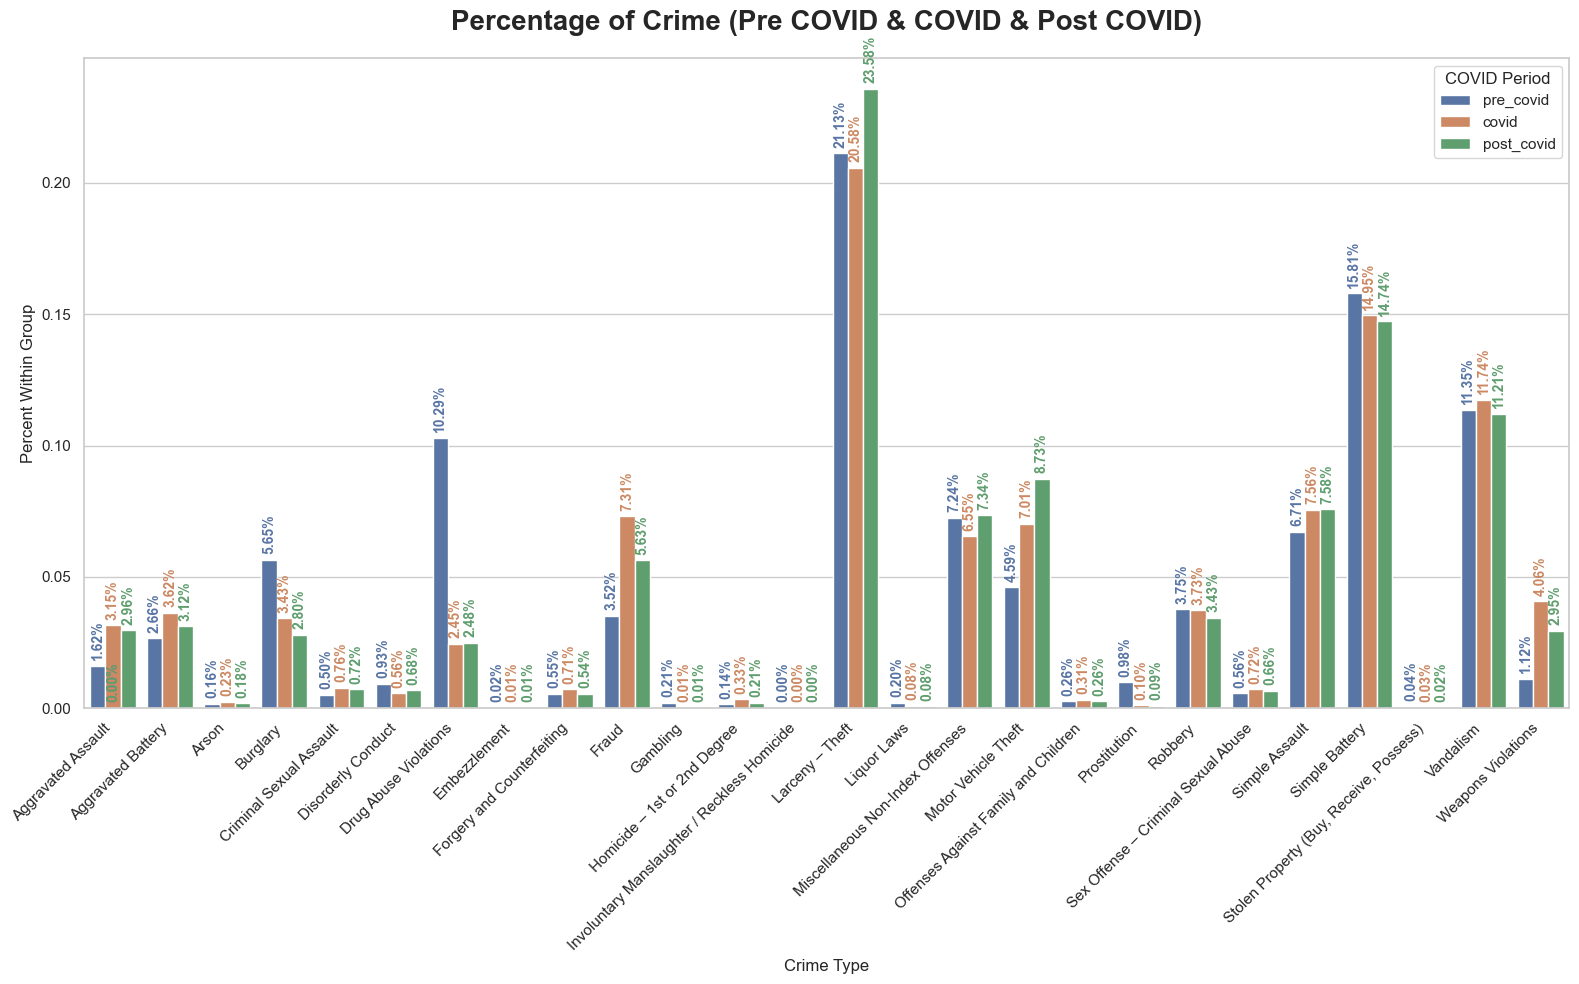

In [16]:
# Convert Arrow dictionary columns to plain Python strings 
df_plot = df_is_covid.reset_index()
df_plot["fbi_code_desc"] = df_plot["fbi_code_desc"].astype(str) 
# df_plot["covid_period"] = df_plot["covid_period"].astype('category')

# Enforce order
covid_order = ["pre_covid", "covid", "post_covid"]
df_plot["covid_period"] = pd.Categorical(
    df_plot["covid_period"],
    categories=covid_order,
    ordered=True
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))
ax = sns.barplot(
    data=df_plot,
    y="crime_proportion",
    x="fbi_code_desc",
    hue="covid_period"
)

for p in ax.patches:
    height = p.get_height()
    color = p.get_facecolor()   # get the bar's actual color

    ax.annotate(
        f"{height:.2%}",                      # always show %
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),                        # fixed offset so labels never vanish
        textcoords="offset points",
        rotation=90,
        color=color,                         # use the bar color for the text
        fontweight='bold',
        clip_on=False                        # don't clip tiny bars
    )
 
plt.title(
    "Percentage of Crime (Pre COVID & COVID & Post COVID)",
    pad=20,
    fontsize = 20,
    fontweight="bold"
)
plt.ylabel("Percent Within Group")
plt.xlabel("Crime Type")
plt.xticks(rotation=45, ha='right')
plt.legend(title="COVID Period")
plt.tight_layout()
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/bar_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

#### Relative Percentage Change

#### $\text{Relative \% Change} = \left( \frac{V_{final} - V_{initial}}{V_{initial}} \right) \times 100$
- % change Pre‑COVID → COVID
- % change Pre‑COVID → Post‑COVID
- % change COVID → Post‑COVID

In [17]:
# Reshape to wide format (COVID vs non‑COVID side‑by‑side)
df_wide = (
    df_is_covid
    .reset_index()
    .astype({"fbi_code_desc": str, "covid_period": str, "crime_count": float, "crime_proportion": float}) # Convert to Pandas
    .pivot(index="fbi_code_desc", columns="covid_period", values=["crime_count", "crime_proportion"])
).reset_index()
# display
df_wide.head()

fbi_code_desc crime_count                       \
covid_period                                covid post_covid pre_covid   
0                  Aggravated Assault     21535.0    20515.0  114800.0   
1                  Aggravated Battery     24767.0    21599.0  188665.0   
2                               Arson      1594.0     1252.0   11637.0   
3                            Burglary     23426.0    19411.0  400596.0   
4             Criminal Sexual Assault      5213.0     4990.0   35729.0   

             crime_proportion                       
covid_period            covid post_covid pre_covid  
0                    0.031496   0.029601  0.016186  
1                    0.036223   0.031165  0.026600  
2                    0.002331   0.001806  0.001641  
3                    0.034262   0.028008  0.056480  
4                    0.007624   0.007200  0.005037

In [18]:
# MultiIndex
crime_proportion = 'crime_proportion'
pct_change_impact = 'pct_change_impact'

# Add new columns
df_wide[(pct_change_impact,'pre_to_covid')] = (
    (df_wide[(crime_proportion, 'covid')] - df_wide[(crime_proportion, 'pre_covid')]) / df_wide[(crime_proportion, 'pre_covid')] * 100
)
df_wide[(pct_change_impact, 'pre_to_post')] = (
    (df_wide[(crime_proportion, 'post_covid')] - df_wide[(crime_proportion, 'pre_covid')]) / df_wide[(crime_proportion, 'pre_covid')] * 100
)
df_wide[(pct_change_impact, 'covid_to_post')] = (
    (df_wide[(crime_proportion, 'post_covid')] - df_wide[(crime_proportion, 'covid')]) / df_wide[(crime_proportion, 'covid')] * 100    
)
# display
df_wide.head()

fbi_code_desc crime_count                       \
covid_period                                covid post_covid pre_covid   
0                  Aggravated Assault     21535.0    20515.0  114800.0   
1                  Aggravated Battery     24767.0    21599.0  188665.0   
2                               Arson      1594.0     1252.0   11637.0   
3                            Burglary     23426.0    19411.0  400596.0   
4             Criminal Sexual Assault      5213.0     4990.0   35729.0   

             crime_proportion                      pct_change_impact  \
covid_period            covid post_covid pre_covid      pre_to_covid   
0                    0.031496   0.029601  0.016186         94.590208   
1                    0.036223   0.031165  0.026600         36.175838   
2                    0.002331   0.001806  0.001641         42.090576   
3                    0.034262   0.028008  0.056480        -39.339006   
4                    0.007624   0.007200  0.005037         51.350847   

                                        
covid_period pre_to_post covid_to_post  
0              82.881184     -6.017273  
1              17.160629    -13.963717  
2              10.103896    -22.511472  
3             -50.411532    -18.253123  
4              42.928579     -5.564732

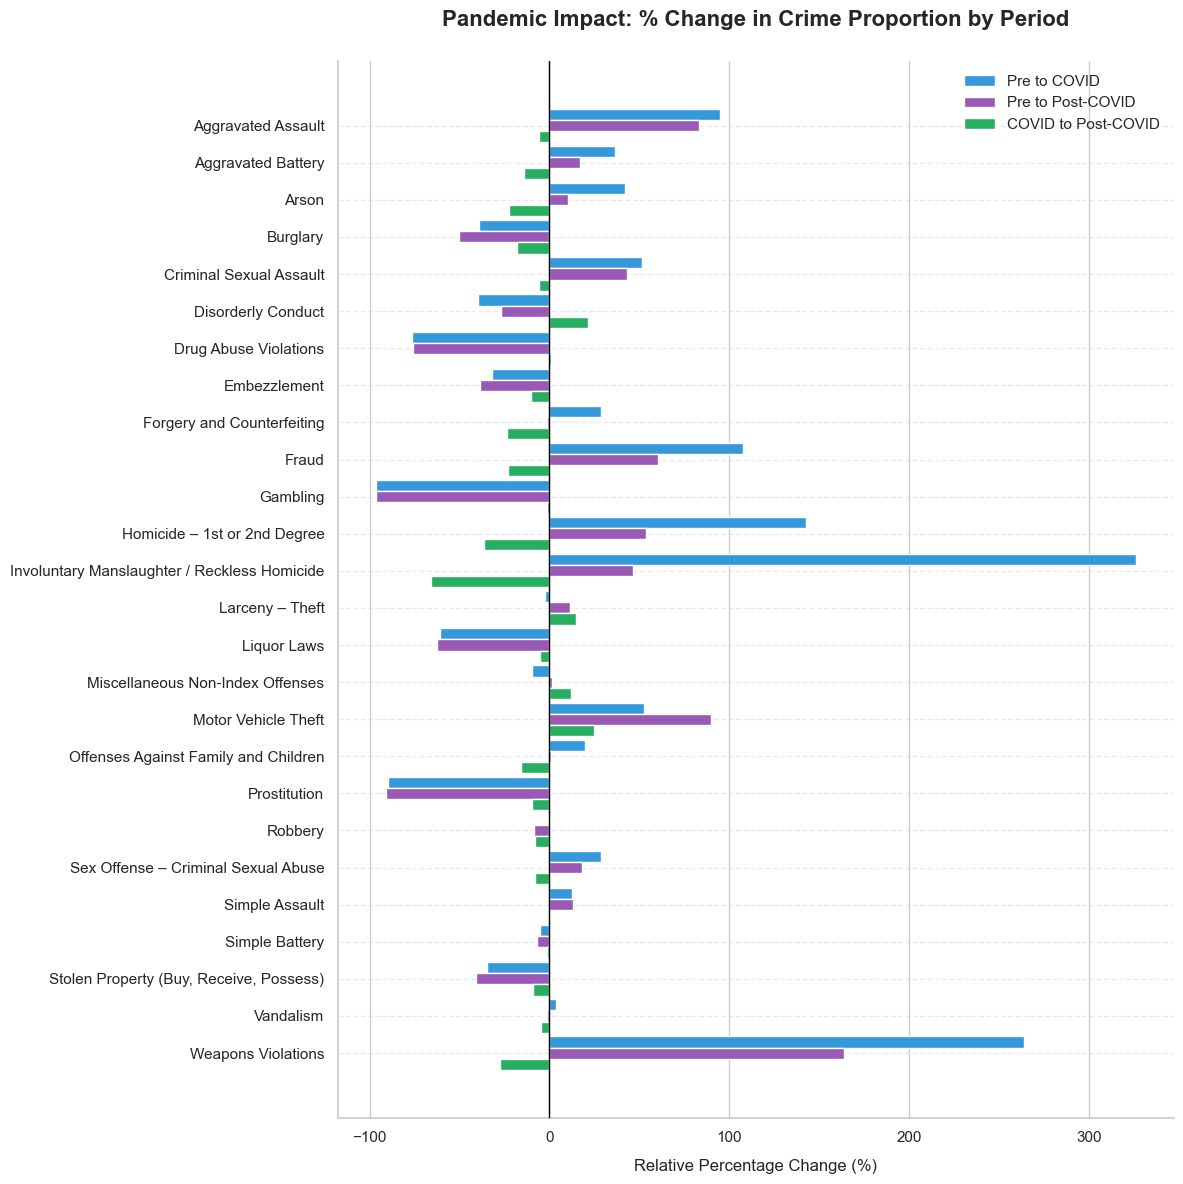

In [19]:
# Set ascending=False so that the first letter (A) appears at the top of the horizontal chart
df_wide = df_wide.sort_values(by='fbi_code_desc', ascending=False)
# plot variables
labels = df_wide['fbi_code_desc']
y = np.arange(len(labels))  # Label locations
height = 0.30  # Width of the bars

# Plot size
fig, ax = plt.subplots(figsize=(12, 12))

# Create grouped bars
rects1 = ax.barh(y + height, df_wide[(pct_change_impact, 'pre_to_covid')], height, label='Pre to COVID', color='#3498db')
rects2 = ax.barh(y, df_wide[(pct_change_impact, 'pre_to_post')], height, label='Pre to Post-COVID', color='#9b59b6')
rects3 = ax.barh(y - height, df_wide[(pct_change_impact, 'covid_to_post')], height, label='COVID to Post-COVID', color='#27ae60')

# Aesthetics
ax.axvline(0, color='black', linewidth=1.0, zorder=3) # Baseline
ax.set_title('Pandemic Impact: % Change in Crime Proportion by Period', fontsize=16, pad=25, fontweight='bold')
ax.set_xlabel('Relative Percentage Change (%)', fontsize=12, labelpad=10)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.legend(frameon=False, loc='upper right')

# Add grid for readability
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Remove chart junk
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
# Save the figure with high resolution and tight cropping
# plt.savefig("../Image/impact_of_covid.png", dpi=1200, bbox_inches='tight')
plt.show()

#### Summary
The dataset provides a fascinating look at how crime patterns shifted across the "Pre-COVID," "COVID," and "Post-COVID" eras. Looking at the raw counts and the percentage changes, a few clear narratives emerge regarding public safety and social behavior during these periods. The data tells a very consistent story: while total volumes for "traditional" street crimes like Burglary or Drug Abuse dropped significantly, the "quality" or severity of crime shifted toward more violent or high-impact categories like Weapons Violations and Motor Vehicle Theft.

* The most jarring shifts occurred in high-impact violent crimes and weapons violations. Even as many other crimes dropped, these categories saw massive growth from the Pre-Covid to Post-Covid eras.
* Homicide (1st or 2nd Degree): Saw a 54.2% increase from Pre-COVID to Post-COVID. Interestingly, it peaked during the Covid period and has since cooled slightly (-36.5% from Covid to Post-Covid), though it remains well above the baseline.
* Weapons Violations: This is the most extreme shift in the table. There was a 165.4% increase from Pre-COVID to Post-COVID.
* Motor Vehicle Theft: A massive surge in the Post-Covid era, up 91.1% compared to the pre-COVID baseline. Unlike Homicide, this trend is still accelerating, growing 29.5% just between the Covid and Post-Covid periods.
* The "Lockdown" Effect (The Declines) Crimes that generally require "face-to-face" interaction or people being out in public spaces saw massive drops, many of which have not returned to previous levels.
* Drug Abuse Violations: Dropped by 76% from Pre-COVID to Post-COVID.Prostitution & Gambling: Both saw near-total collapses (down 91% and 96.7% respectively), likely due to the closure of physical venues and shifts in police priorities.
* Burglary: Dropped by 50.5% Post-Covid. This is often attributed to more people working from home, making residential targets "occupied" and therefore riskier for burglars.
* The Fraud stands out as an outlier. It spiked by 61% from pre-COVID to post-COVID. However, the data shows an incredibly high "Impact" score during the Covid period (108.9%), suggesting a massive wave of activity (potentially related to relief fund scams or digital shift) that has begun to subside.
* Comparison of Key Offenses (Proportions of Total Crime): The shift in the "nature" of crime is best seen in the Crime Proportion columns. While Larceny-Theft remains the most common crime (roughly 21-23% of all records), other categories shifted the "makeup" of the city's crime profile:

In [20]:
multi_counts.head()

fbi_code_desc       quarter  month     day_of_week  time_of_day  Indexed  year_week  covid_period
Aggravated Assault  Q1       February  Friday       Afternoon    I        2001-05    pre_covid       3
                                                                          2001-06    pre_covid       3
                                                                          2001-07    pre_covid       6
                                                                          2001-08    pre_covid       5
                                                                          2002-05    pre_covid       1
dtype: int64

In [21]:
# Group by the level name and sum up the sizes
week_counts = (
    multi_counts.groupby(level=['fbi_code_desc', 'Indexed', 'year_week', 'covid_period'])
    .sum()
    .reset_index(name='count')
    .astype({'count': 'int64[pyarrow]'})
             )
# display
print(week_counts.isna().any())
week_counts.sort_values(['fbi_code_desc', 'year_week'])
week_counts.head()

fbi_code_desc    False
Indexed          False
year_week        False
covid_period     False
count            False
dtype: bool


,fbi_code_desc,Indexed,year_week,covid_period,count
0,Aggravated Assault,I,2001-01,pre_covid,133
1,Aggravated Assault,I,2001-02,pre_covid,128
2,Aggravated Assault,I,2001-03,pre_covid,112
3,Aggravated Assault,I,2001-04,pre_covid,119
4,Aggravated Assault,I,2001-05,pre_covid,127


In [22]:
# Distinct Crime Type Values
print(list(multi_counts.index.get_level_values('fbi_code_desc').unique()))

['Aggravated Assault', 'Aggravated Battery', 'Arson', 'Burglary', 'Criminal Sexual Assault', 'Disorderly Conduct', 'Drug Abuse Violations', 'Embezzlement', 'Forgery and Counterfeiting', 'Fraud', 'Gambling', 'Homicide – 1st or 2nd Degree', 'Involuntary Manslaughter / Reckless Homicide', 'Larceny – Theft', 'Liquor Laws', 'Miscellaneous Non-Index Offenses', 'Motor Vehicle Theft', 'Offenses Against Family and Children', 'Prostitution', 'Robbery', 'Sex Offense – Criminal Sexual Abuse', 'Simple Assault', 'Simple Battery', 'Stolen Property (Buy, Receive, Possess)', 'Vandalism', 'Weapons Violations']


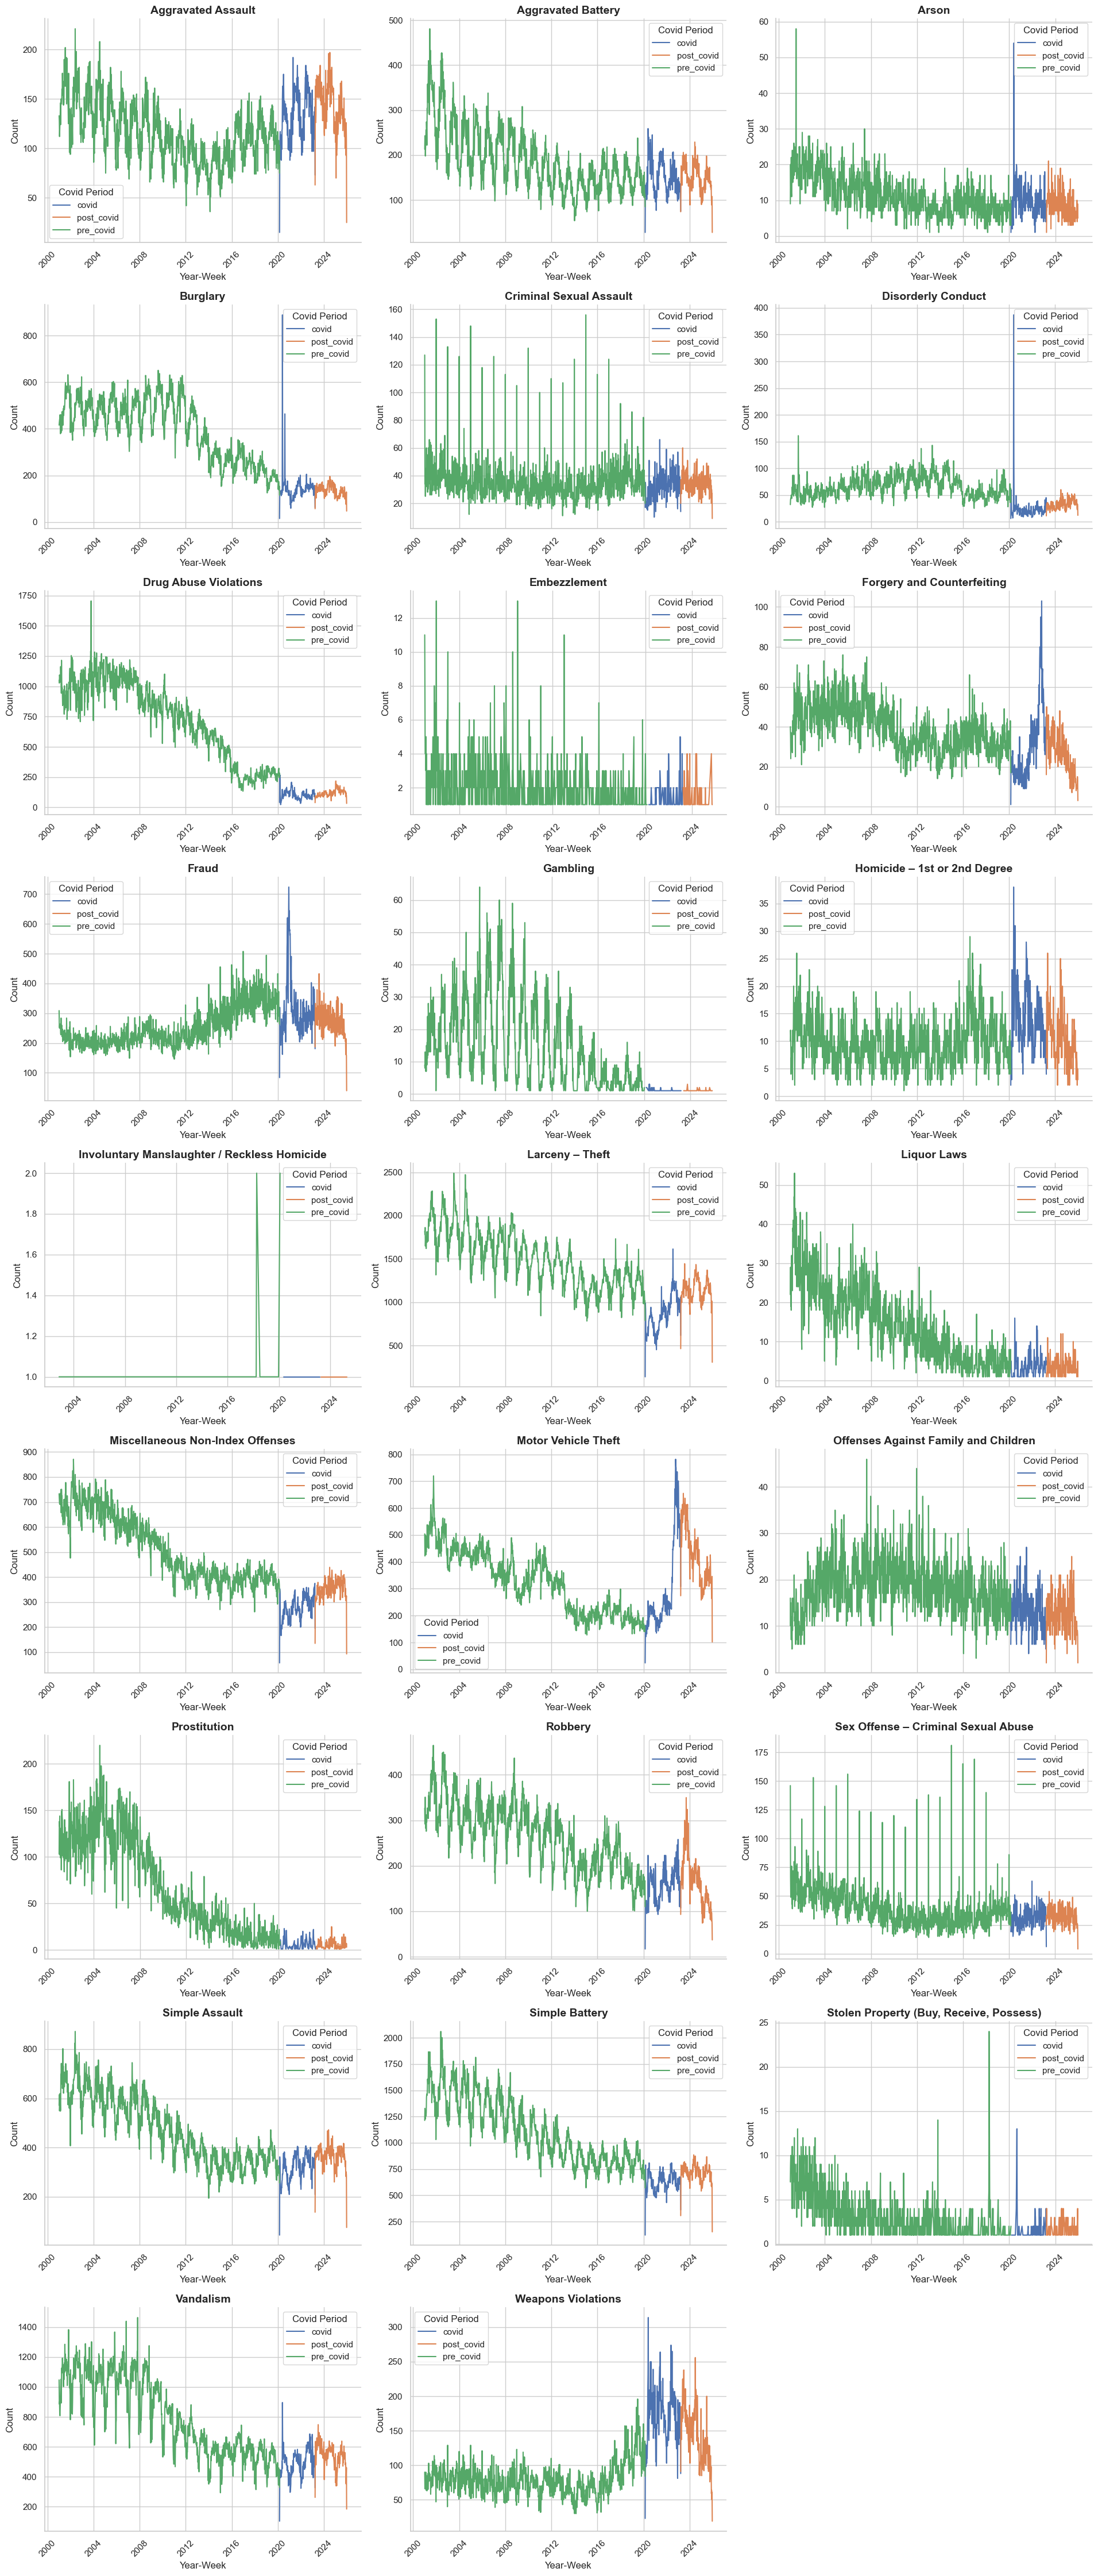

In [23]:
# Convert to Plot-friendly format
convert = week_counts.assign(
    year_week=lambda d: pd.to_datetime(d["year_week"] + "-1", format="%G-%V-%u"),
    count=lambda d: d["count"].astype("float64"),
    covid_period=lambda d: d["covid_period"].astype("category"),
    fbi_code_desc=lambda d: d["fbi_code_desc"].astype("string")
)
# create a FacetGrid of line plots object
g = sns.relplot(
    data=convert,
    x="year_week",
    y="count",
    hue="covid_period",
    col="fbi_code_desc",
    col_wrap=3,
    kind="line",
    height=5,
    aspect=1.2,
    facet_kws={'sharey': False, 'sharex': False},
    legend=True # Keep this True initially so labels are generated
)

# Extract labels and handles from the global legend before removing
handles, labels = g._legend.legend_handles, [t.get_text() for t in g._legend.get_texts()]

# Remove the default global legend
g._legend.remove()

# Fix titles
g.set_titles(col_template="{col_name}", size=14, weight='bold')

# Iterate through axes to format and add the legend manually
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=45)   
    # Manually pass the handles and labels we extracted
    ax.legend(handles=handles, labels=labels, title="Covid Period")
    ax.set_xlabel("Year-Week")
    ax.set_ylabel("Count")

plt.tight_layout()
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/time_line_crime_plot.png", bbox_inches='tight')
plt.show()

In [24]:
convert.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31538 entries, 0 to 31537
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype                                                       
---  ------         --------------  -----                                                       
 0   fbi_code_desc  31538 non-null  string                                                      
 1   Indexed        31538 non-null  dictionary<values=string, indices=int32, ordered=0>[pyarrow]
 2   year_week      31538 non-null  datetime64[ns]                                              
 3   covid_period   31538 non-null  category                                                    
 4   count          31538 non-null  float64                                                     
dtypes: category(1), datetime64[ns](1), dictionary<values=string, indices=int32, ordered=0>[pyarrow](1), float64(1), string(1)
memory usage: 893.4 KB


## Indexed Plot

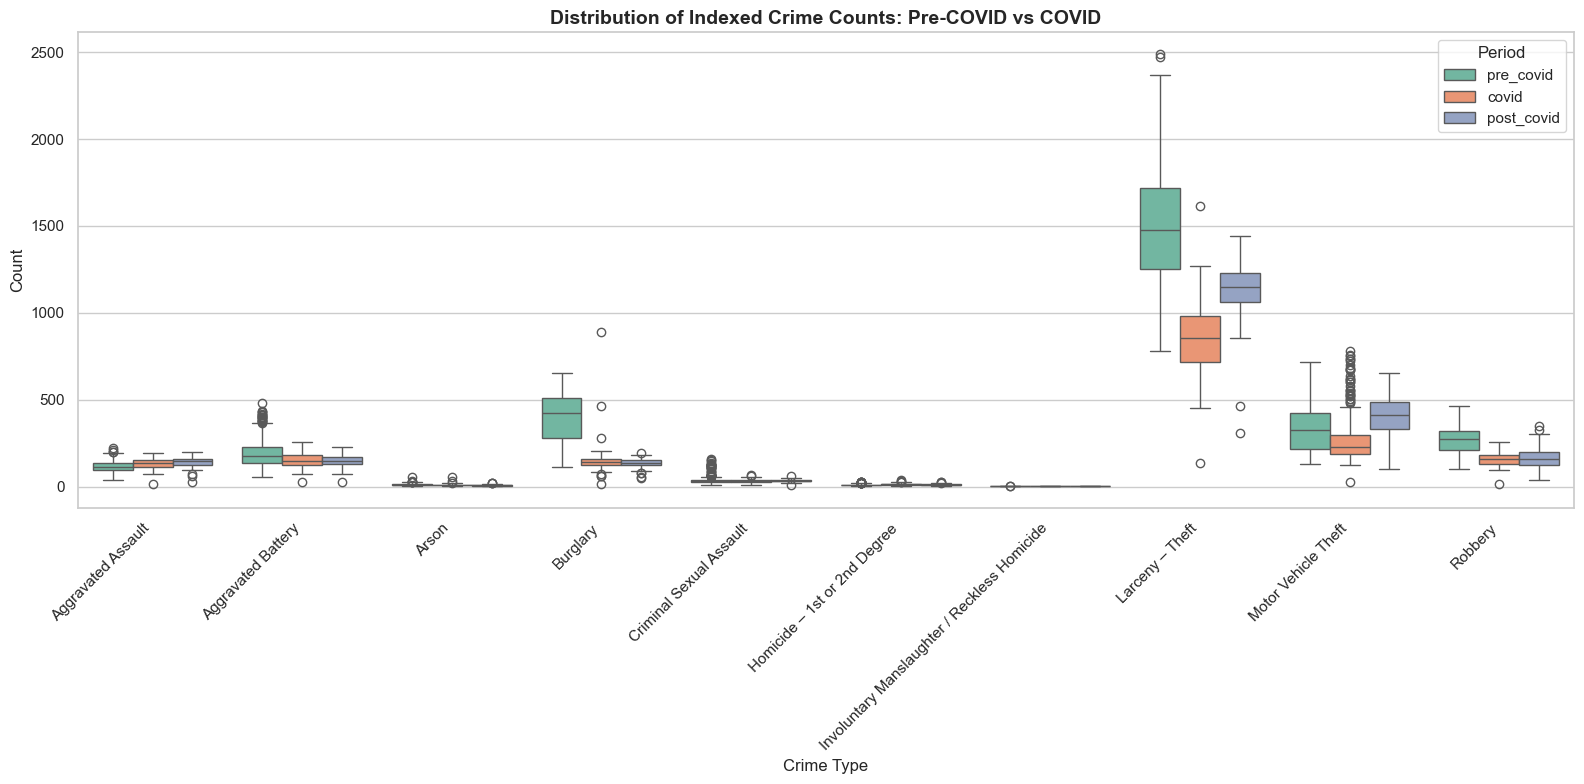

In [25]:
# Define your desired order
legend_order = ["pre_covid", "covid", "post_covid"]
legend_title = "Period"

# plot size
plt.figure(figsize=(16, 8))

# Add 'hue_order' to the boxplot call
ax = sns.boxplot(
    data=convert.loc[convert.Indexed == 'I'],
    x="fbi_code_desc",
    y="count",
    hue="covid_period",
    hue_order=legend_order,  # Ensures boxes follow the specific order
    palette="Set2"
)
# labels
plt.xticks(rotation=45, ha='right')
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.title("Distribution of Indexed Crime Counts: Pre-COVID vs COVID", size=14, weight='bold')

# legend handling
ax.legend(title=legend_title, frameon=True)

plt.tight_layout()
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/box_indexed_crime_plot.png", bbox_inches='tight')
plt.show()

## Non-Indexed

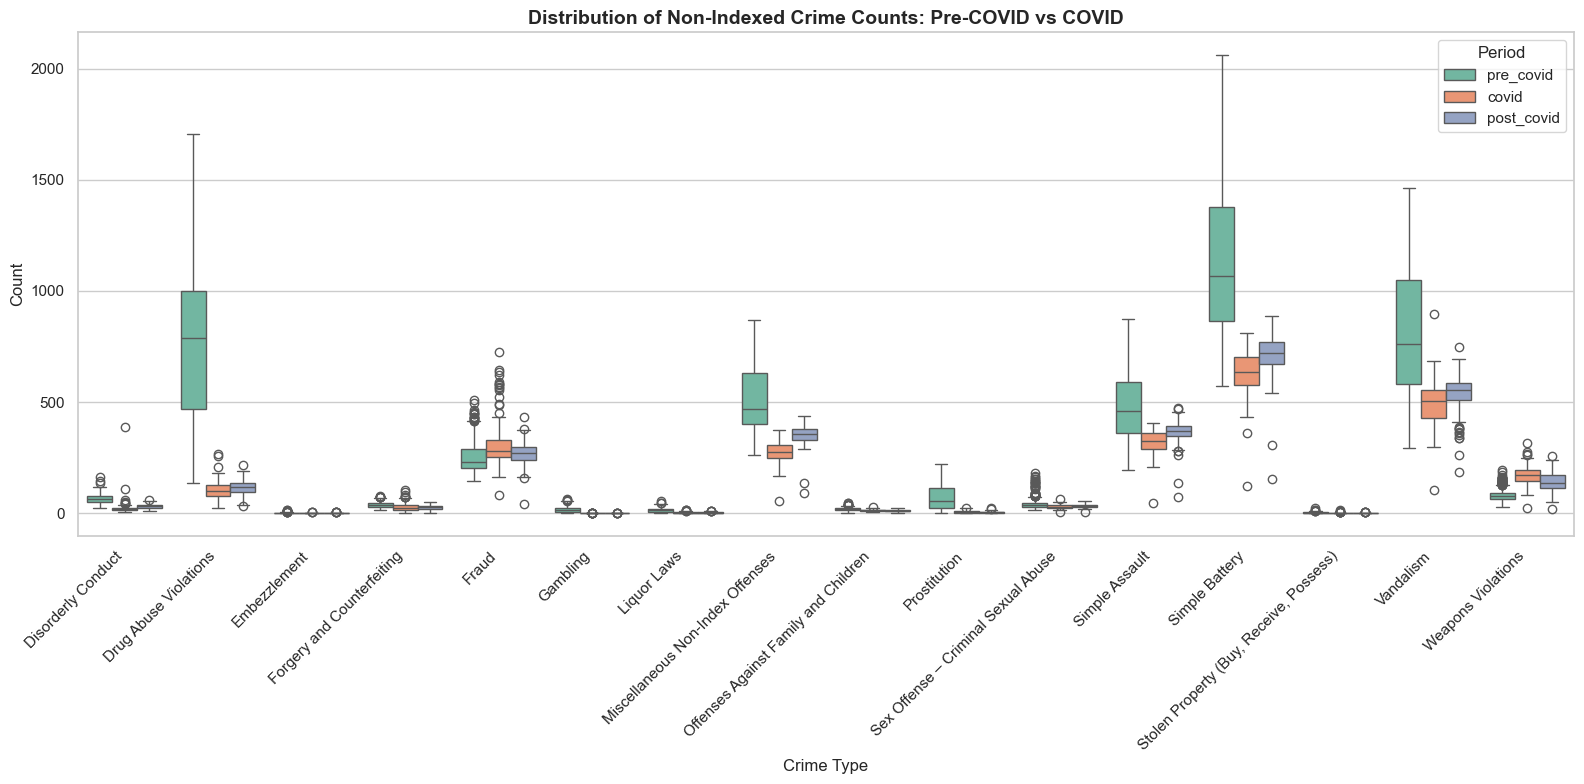

In [26]:
# Define your desired order
legend_order = ["pre_covid", "covid", "post_covid"]
legend_title = "Period"

# plot size
plt.figure(figsize=(16, 8))

# Add 'hue_order' to the boxplot call
ax = sns.boxplot(
    data=convert.loc[convert.Indexed == 'N'],
    x="fbi_code_desc",
    y="count",
    hue="covid_period",
    hue_order=legend_order,  # Ensures boxes follow the specific order
    palette="Set2"
)
# labels
plt.xticks(rotation=45, ha='right')
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.title("Distribution of Non-Indexed Crime Counts: Pre-COVID vs COVID", size=14, weight='bold')

# legend handling
ax.legend(title=legend_title, frameon=True)

# Save the figure with high resolution and tight cropping
plt.savefig("../Image/box_nonindexed_crime_plot.png", bbox_inches='tight')

plt.tight_layout()
plt.show()

## Save using PyArrow

In [27]:
# Save as Arrow
df.to_feather("../Data/crime_data_covid.feather")